In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
from skimage.metrics import structural_similarity, mean_squared_error

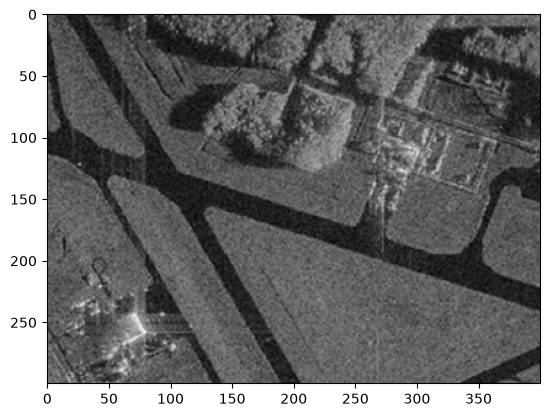

In [2]:
image = cv2.imread('sar_4.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

In [3]:
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.

In [4]:
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])
                                                            
    if abs(av_val - img[point]) <= T:
        return True
    
    return False

In [5]:
def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r,image.shape[0] - r):
            for j in range(r,image.shape[1] - r):
                if mask[i,j]==0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        print(count)
        mask += local_mask
        
    return mask*255

188
522
845
1017
1123
1176
1204
1199
1179
1196
1207
1274
1499
1160
1097
1208
1321
1443
1651
1992
1994
2016
2062
1935
1951
2071
2767
2491
2119
1573
1746
1658
1650
1618
1571
1651
2469
1988
1374
728
868
1044
465
384
393
456
497
490
469
402
534
632
650
434
343
341
379
397
366
234
108
68
11
0


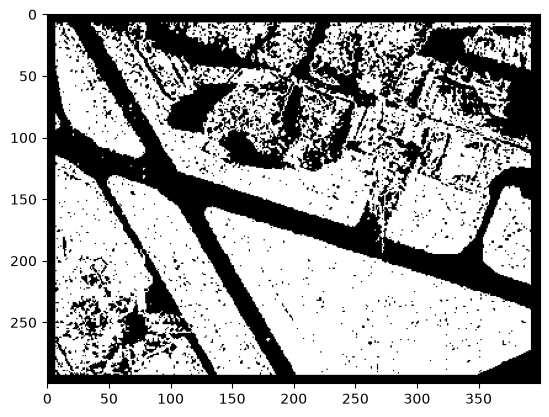

In [6]:
seed_point = (200, 200)
mask = region_growing(image_gray, seed_point, homo_average, 7, 20)
plt.imshow(mask, cmap="gray")

In [7]:
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.

In [8]:
def homo_median(img, mask, point, T):
    region = img[mask > 0]
    if len(region) == 0:
        return False
    median_val = np.median(region)
    if abs(median_val - img[point]) <= T:
        return True
    return False

In [9]:
seed_point = (200, 200)
mask_median = region_growing(image_gray, seed_point, homo_median, 7, 20)

(ssim_average, _) = structural_similarity(image_gray, mask, full=True)
(ssim_median, _) = structural_similarity(image_gray, mask_median, full=True)

mse_average = mean_squared_error(image_gray, mask)
mse_median = mean_squared_error(image_gray, mask_median)

188
523
849
1021
1128
1180
1187
1201
1181
1233
1211
1287
1450
1162
1097
1213
1422
1458
1670
1866
2000
2029
2269
1970
1974
2096
2499
2502
2458
1598
1778
1690
1685
1655
1613
1675
1937
2007
1381
739
877
1066
468
386
393
457
1228
512
581
608
647
569
495
403
352
357
394
380
304
229
94
70
12
0


Average: MSE -  16704.315583333333 SSIM -  0.11584811660291794


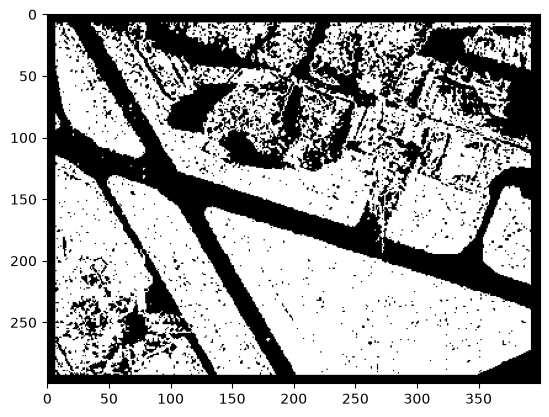

In [10]:
plt.imshow(mask, cmap='gray')
print("Average: MSE - ", mse_average, "SSIM - ", ssim_average)

Median: MSE -  16877.439333333332 SSIM -  0.1217895607789087


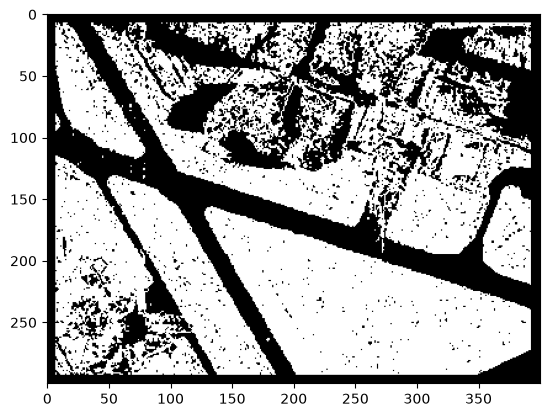

In [11]:
plt.imshow(mask_median, cmap='gray')
print("Median: MSE - ", mse_median, "SSIM - ", ssim_median)

In [12]:
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

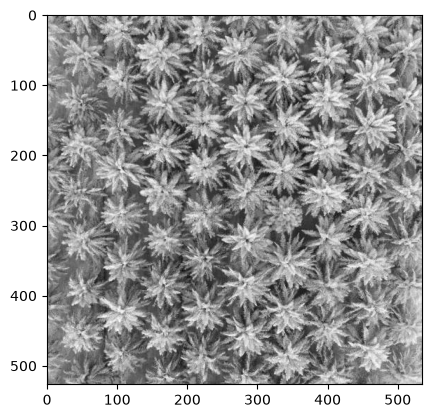

In [13]:
image = cv2.imread('palm_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

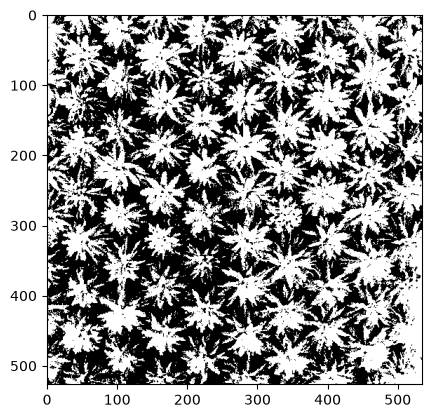

In [14]:
ret, thresh = cv2.threshold(image_gray,0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(thresh, cmap="gray")

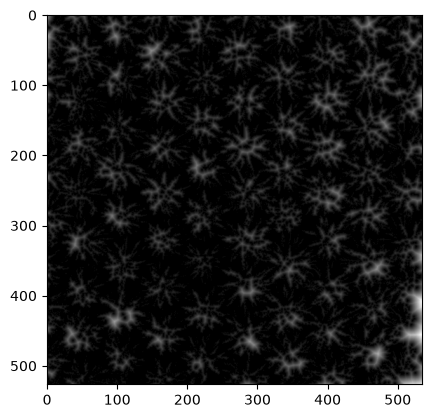

In [15]:
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
plt.imshow(dist, cmap="gray")

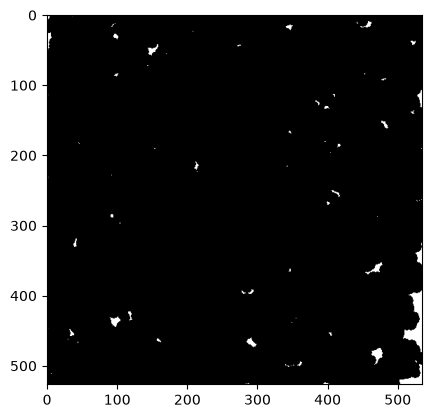

In [49]:
ret, sure_fg = cv2.threshold(dist, 0.37 * dist.max(), 255, cv2.THRESH_BINARY)
plt.imshow(sure_fg, cmap="gray")

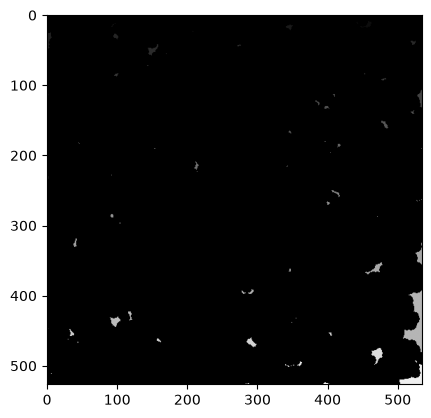

In [50]:
sure_fg = sure_fg.astype(np.uint8)
ret, markers = cv2.connectedComponents(sure_fg)
plt.imshow(markers, cmap="gray")

Всего пальм: 73


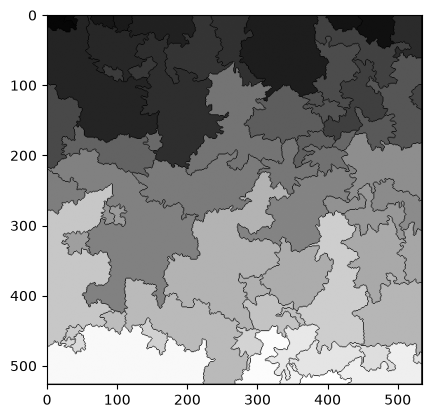

In [51]:
markers = cv2.watershed(image, markers)
plt.imshow(markers, cmap="gray")
print('Всего пальм:', len(np.unique(markers)))